In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlepad"] = 14

PALETTE = "Set2"

BENCH_DIR = Path.cwd().parent / "benchmark_output"
AGG_PATH = BENCH_DIR / "benchmark_aggregated_faces.csv"
GRAN_PATH = BENCH_DIR / "benchmark_granular_faces.csv"

print(f"Loading benchmarks from: {BENCH_DIR}")
agg = pd.read_csv(AGG_PATH)
granular = pd.read_csv(GRAN_PATH)
print(f"  aggregated rows: {len(agg)}")
print(f"  granular rows:   {len(granular)}")

Loading benchmarks from: /home/dxzielinski/Desktop/github-repositories/streaming-ml/benchmark_output
  aggregated rows: 7
  granular rows:   70


In [2]:
DETECTOR_LABELS = {
    "mmd": "MMD",
    "frechet": "Frechet",
    "kswin": "KSWIN",
    "adwin": "ADWIN",
    "hddm_w": "HDDM-W",
    "page_hinkley": "Page-Hinkley",
}

DRIFT_TYPE_LABELS = {
    "sudden": "Sudden",
    "gradual": "Gradual",
    "gradual_recurrent": "Gradual recurrent",
    "incremental": "Incremental",
}

MODALITY_LABELS = {
    "image": "Image",
    "text": "Text",
    "both": "Multimodal",
}


def pretty(mapping: dict[str, str], key: str) -> str:
    return mapping.get(key, key)


def add_pretty_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["detector_pretty"] = out["detector"].map(lambda x: pretty(DETECTOR_LABELS, x))
    out["drift_type_pretty"] = out["drift_type"].map(
        lambda x: pretty(DRIFT_TYPE_LABELS, x)
    )
    out["modality_pretty"] = out["modality"].map(lambda x: pretty(MODALITY_LABELS, x))
    return out


agg = add_pretty_columns(agg)
granular = add_pretty_columns(granular)

agg.head()

,drift_target,detector,drift_type,modality,trials,recall_mean,recall_std,recall_count,precision_mean,precision_std,...,classifier_case1_accuracy_count,classifier_case2_accuracy_mean,classifier_case2_accuracy_std,classifier_case2_accuracy_count,classifier_case2_replacements_mean,classifier_case2_replacements_std,classifier_case2_replacements_count,detector_pretty,drift_type_pretty,modality_pretty
0,data,frechet,gradual_recurrent,both,10,0.733333,0.250924,10,0.413183,0.253180,...,0,NaN,NaN,0,NaN,NaN,0,Frechet,Gradual recurrent,Multimodal
1,data,kswin,gradual_recurrent,both,10,0.650000,0.308821,10,0.345556,0.186179,...,0,NaN,NaN,0,NaN,NaN,0,KSWIN,Gradual recurrent,Multimodal
2,data,mmd,gradual_recurrent,both,10,0.733333,0.370185,10,0.401073,0.224485,...,0,NaN,NaN,0,NaN,NaN,0,MMD,Gradual recurrent,Multimodal
3,performance,adwin,gradual_recurrent,both,10,0.000000,0.000000,10,0.000000,0.000000,...,10,0.6159,0.021414,10,0.0,0.000000,10,ADWIN,Gradual recurrent,Multimodal
4,performance,hddm_w,gradual_recurrent,both,10,0.116667,0.249072,10,0.150000,0.337474,...,10,0.6035,0.026459,10,1.3,0.948683,10,HDDM-W,Gradual recurrent,Multimodal


In [3]:
def _detector_order(df: pd.DataFrame) -> list[str]:
    return sorted(df["detector_pretty"].unique().tolist())


def grouped_bar(
    df: pd.DataFrame,
    *,
    metric_mean: str,
    metric_std: str,
    title: str,
    ylabel: str,
    hue_col: str = "drift_type_pretty",
    ax: plt.Axes | None = None,
    value_fmt: str = "{:.2f}",
    ylim: tuple[float, float] | None = None,
    log: bool = False,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    if df.empty or df[metric_mean].dropna().empty:
        ax.text(
            0.5,
            0.5,
            "No data available",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=14,
            color="gray",
        )
        ax.set_title(title)
        ax.set_axis_off()
        return ax

    detectors = _detector_order(df)
    hues = sorted(df[hue_col].dropna().unique().tolist())
    n_h = max(len(hues), 1)
    width = 0.8 / n_h
    x = np.arange(len(detectors))

    colors = sns.color_palette(PALETTE, n_h)

    for i, hue in enumerate(hues):
        sub = df[df[hue_col] == hue].set_index("detector_pretty").reindex(detectors)
        means = sub[metric_mean].to_numpy(dtype=float)
        stds = sub[metric_std].to_numpy(dtype=float)
        offset = (i - (n_h - 1) / 2) * width
        bars = ax.bar(
            x + offset,
            means,
            width=width * 0.95,
            yerr=stds,
            capsize=4,
            label=hue,
            color=colors[i],
            edgecolor="black",
            linewidth=0.6,
            error_kw={"elinewidth": 1.2, "alpha": 0.85},
        )
        for bar, val in zip(bars, means):
            if np.isnan(val):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                value_fmt.format(val),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="semibold",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(detectors, rotation=0)
    ax.set_xlabel("Detector")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if log:
        ax.set_yscale("log")
    if n_h > 1:
        ax.legend(
            title=hue_col.replace("_pretty", "").replace("_", " ").title(),
            frameon=False,
        )
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
    ax.spines[["top", "right"]].set_visible(False)
    return ax


def show_no_data(title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.text(
        0.5,
        0.5,
        "No data available for this slice",
        ha="center",
        va="center",
        fontsize=14,
        color="gray",
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

In [4]:
def slice_target(df: pd.DataFrame, target: str) -> pd.DataFrame:
    return df[df["drift_target"] == target].copy()


data_agg = slice_target(agg, "data")
data_gran = slice_target(granular, "data")

perf_agg = slice_target(agg, "performance")
perf_gran = slice_target(granular, "performance")

print(
    f"data slice:        {len(data_agg)} aggregated rows / {len(data_gran)} granular trials\n"
    f"performance slice: {len(perf_agg)} aggregated rows / {len(perf_gran)} granular trials"
)

data slice:        3 aggregated rows / 30 granular trials
performance slice: 4 aggregated rows / 40 granular trials


## 1. Detection quality &mdash; Recall, Precision, F1

How reliably does each detector flag real drift events without crying wolf? Bars show the trial mean; whiskers show one standard deviation across trials.

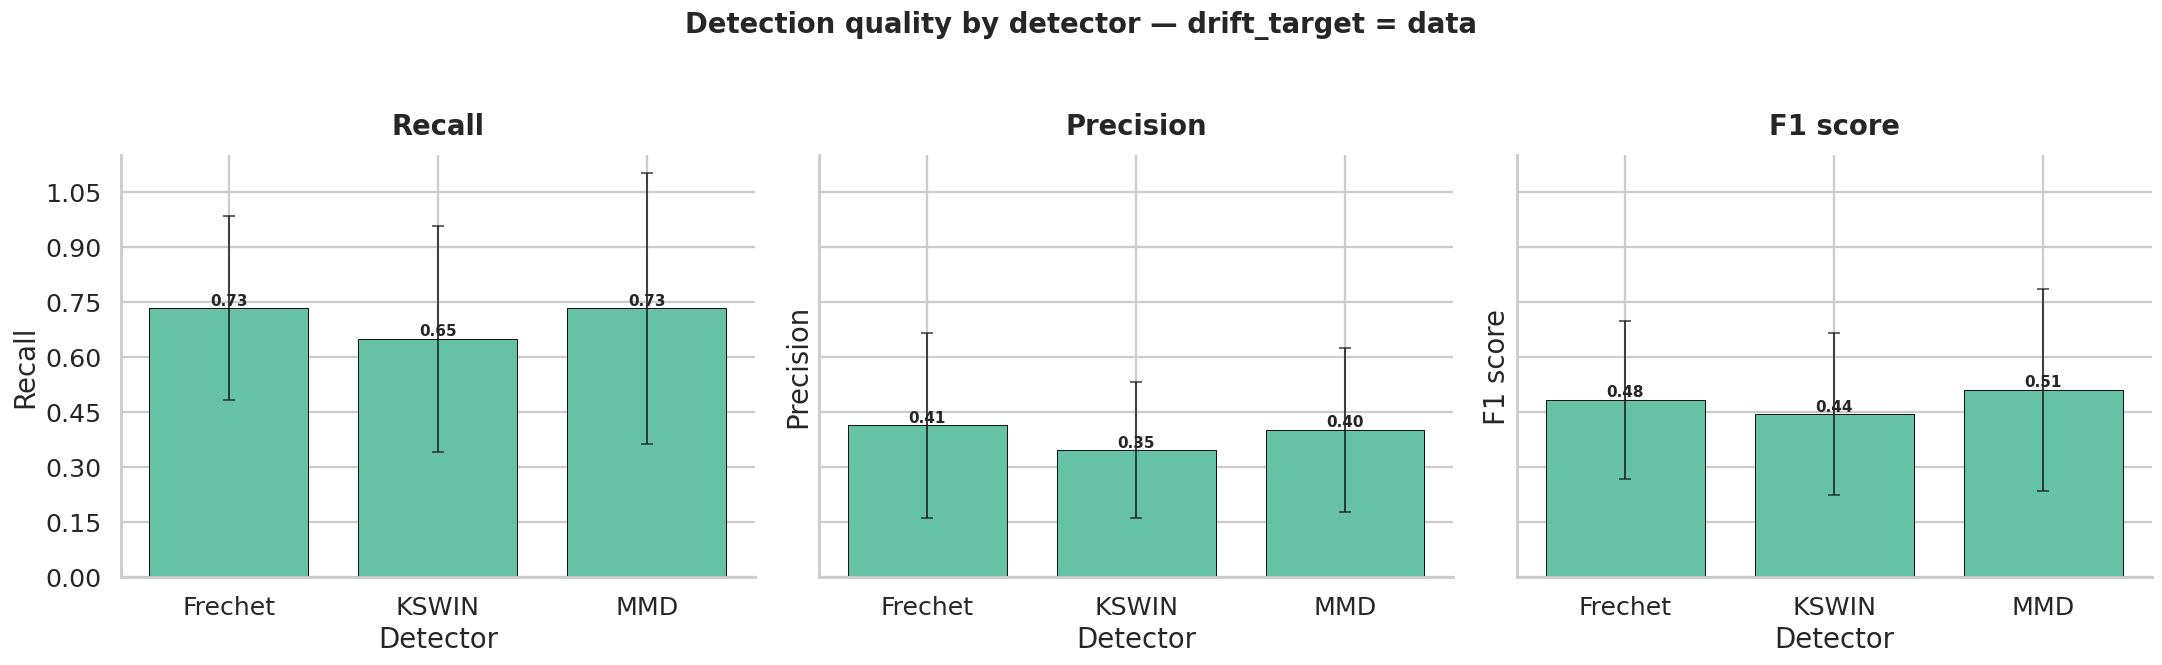

In [5]:
def plot_detection_quality(slice_df: pd.DataFrame, target_label: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    metrics = [
        ("recall_mean", "recall_std", "Recall"),
        ("precision_mean", "precision_std", "Precision"),
        ("f1_mean", "f1_std", "F1 score"),
    ]
    for ax, (m, s, name) in zip(axes, metrics):
        grouped_bar(
            slice_df,
            metric_mean=m,
            metric_std=s,
            title=name,
            ylabel=name,
            ax=ax,
            ylim=(0, 1.15),
        )
    fig.suptitle(
        f"Detection quality by detector \u2014 drift_target = {target_label}",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


plot_detection_quality(data_agg, "data")

## 2. Detection latency &mdash; how soon is drift caught?

*Mean detection delay* is measured in samples after the true drift onset. Lower is better. Detectors that miss every drift contribute no delay value, which is reflected in `mean_detection_delay_count`.

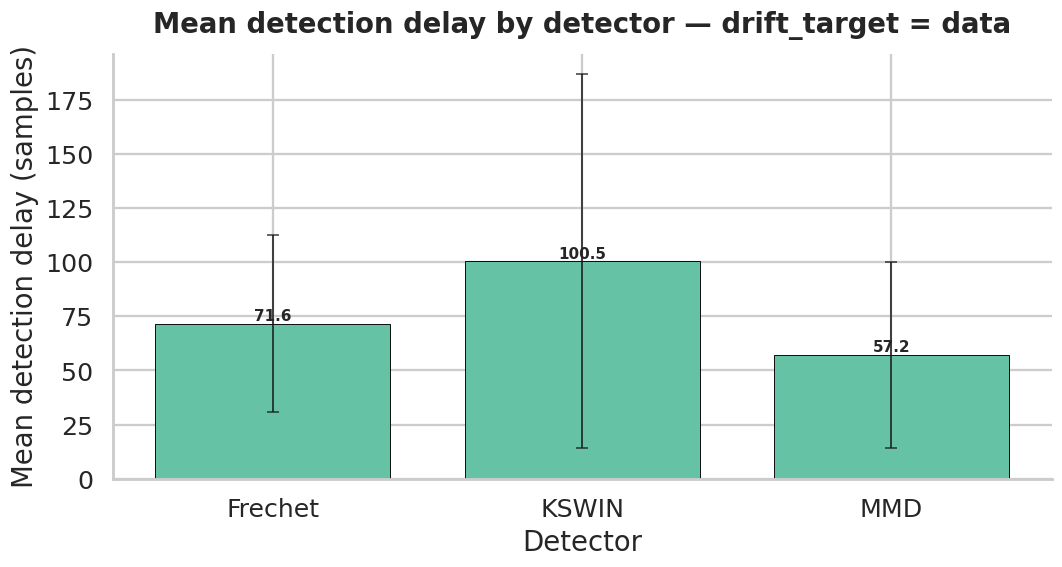

In [6]:
def plot_detection_delay(slice_df: pd.DataFrame, target_label: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    grouped_bar(
        slice_df,
        metric_mean="mean_detection_delay_mean",
        metric_std="mean_detection_delay_std",
        title=f"Mean detection delay by detector \u2014 drift_target = {target_label}",
        ylabel="Mean detection delay (samples)",
        ax=ax,
        value_fmt="{:.1f}",
    )
    plt.tight_layout()
    plt.show()


plot_detection_delay(data_agg, "data")

### Per-trial spread of detection delay

Box-and-strip plot from the granular CSV. Each dot is one trial &mdash; useful to spot detectors whose delay varies wildly between seeds.

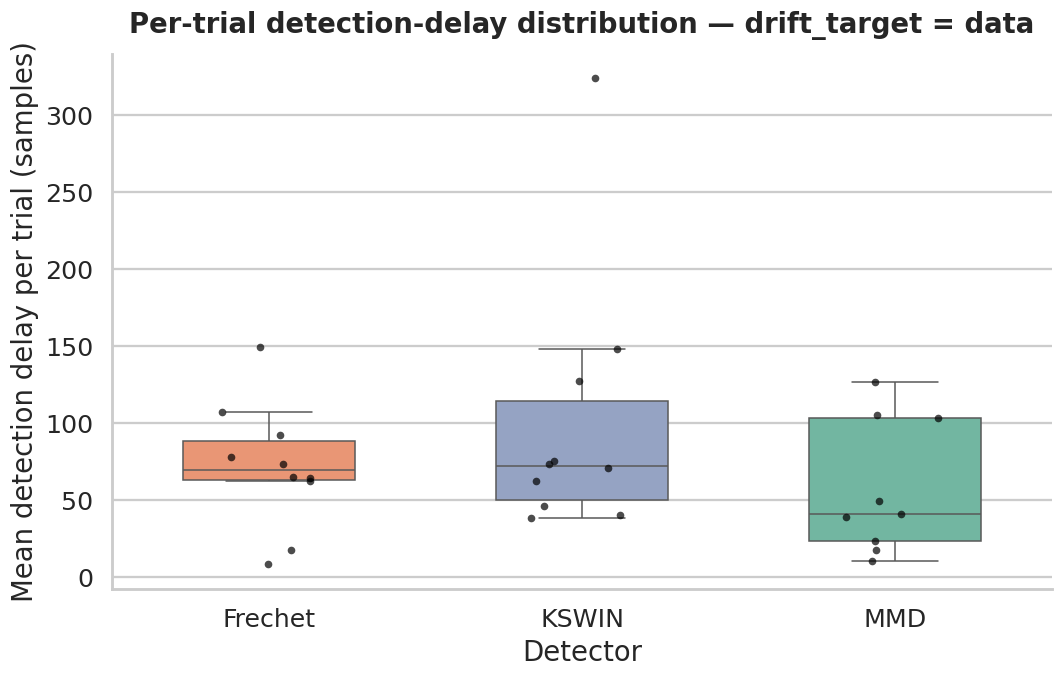

In [7]:
def plot_delay_distribution(slice_gran: pd.DataFrame, target_label: str) -> None:
    df = slice_gran.dropna(subset=["mean_detection_delay"]).copy()
    if df.empty:
        show_no_data(f"Per-trial detection delay \u2014 drift_target = {target_label}")
        return
    order = sorted(df["detector_pretty"].unique())
    fig, ax = plt.subplots(figsize=(10, 6.5))
    sns.boxplot(
        data=df,
        x="detector_pretty",
        y="mean_detection_delay",
        order=order,
        ax=ax,
        hue="detector_pretty",
        palette=PALETTE,
        legend=False,
        width=0.55,
        showfliers=False,
    )
    sns.stripplot(
        data=df,
        x="detector_pretty",
        y="mean_detection_delay",
        order=order,
        ax=ax,
        color="black",
        size=5,
        alpha=0.7,
        jitter=0.18,
    )
    ax.set_xlabel("Detector")
    ax.set_ylabel("Mean detection delay per trial (samples)")
    ax.set_title(
        f"Per-trial detection-delay distribution \u2014 drift_target = {target_label}"
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_delay_distribution(data_gran, "data")

## 3. Computational cost

How expensive is each detector at run-time? We look at four complementary views:

* **Per-sample latency** &mdash; `mean_total_time_ms` (embedding + detector update)
* **Throughput** &mdash; samples processed per second
* **Time decomposition** &mdash; embedding vs detector contribution
* **Total wall-clock** &mdash; how long the whole 1k-sample stream took

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

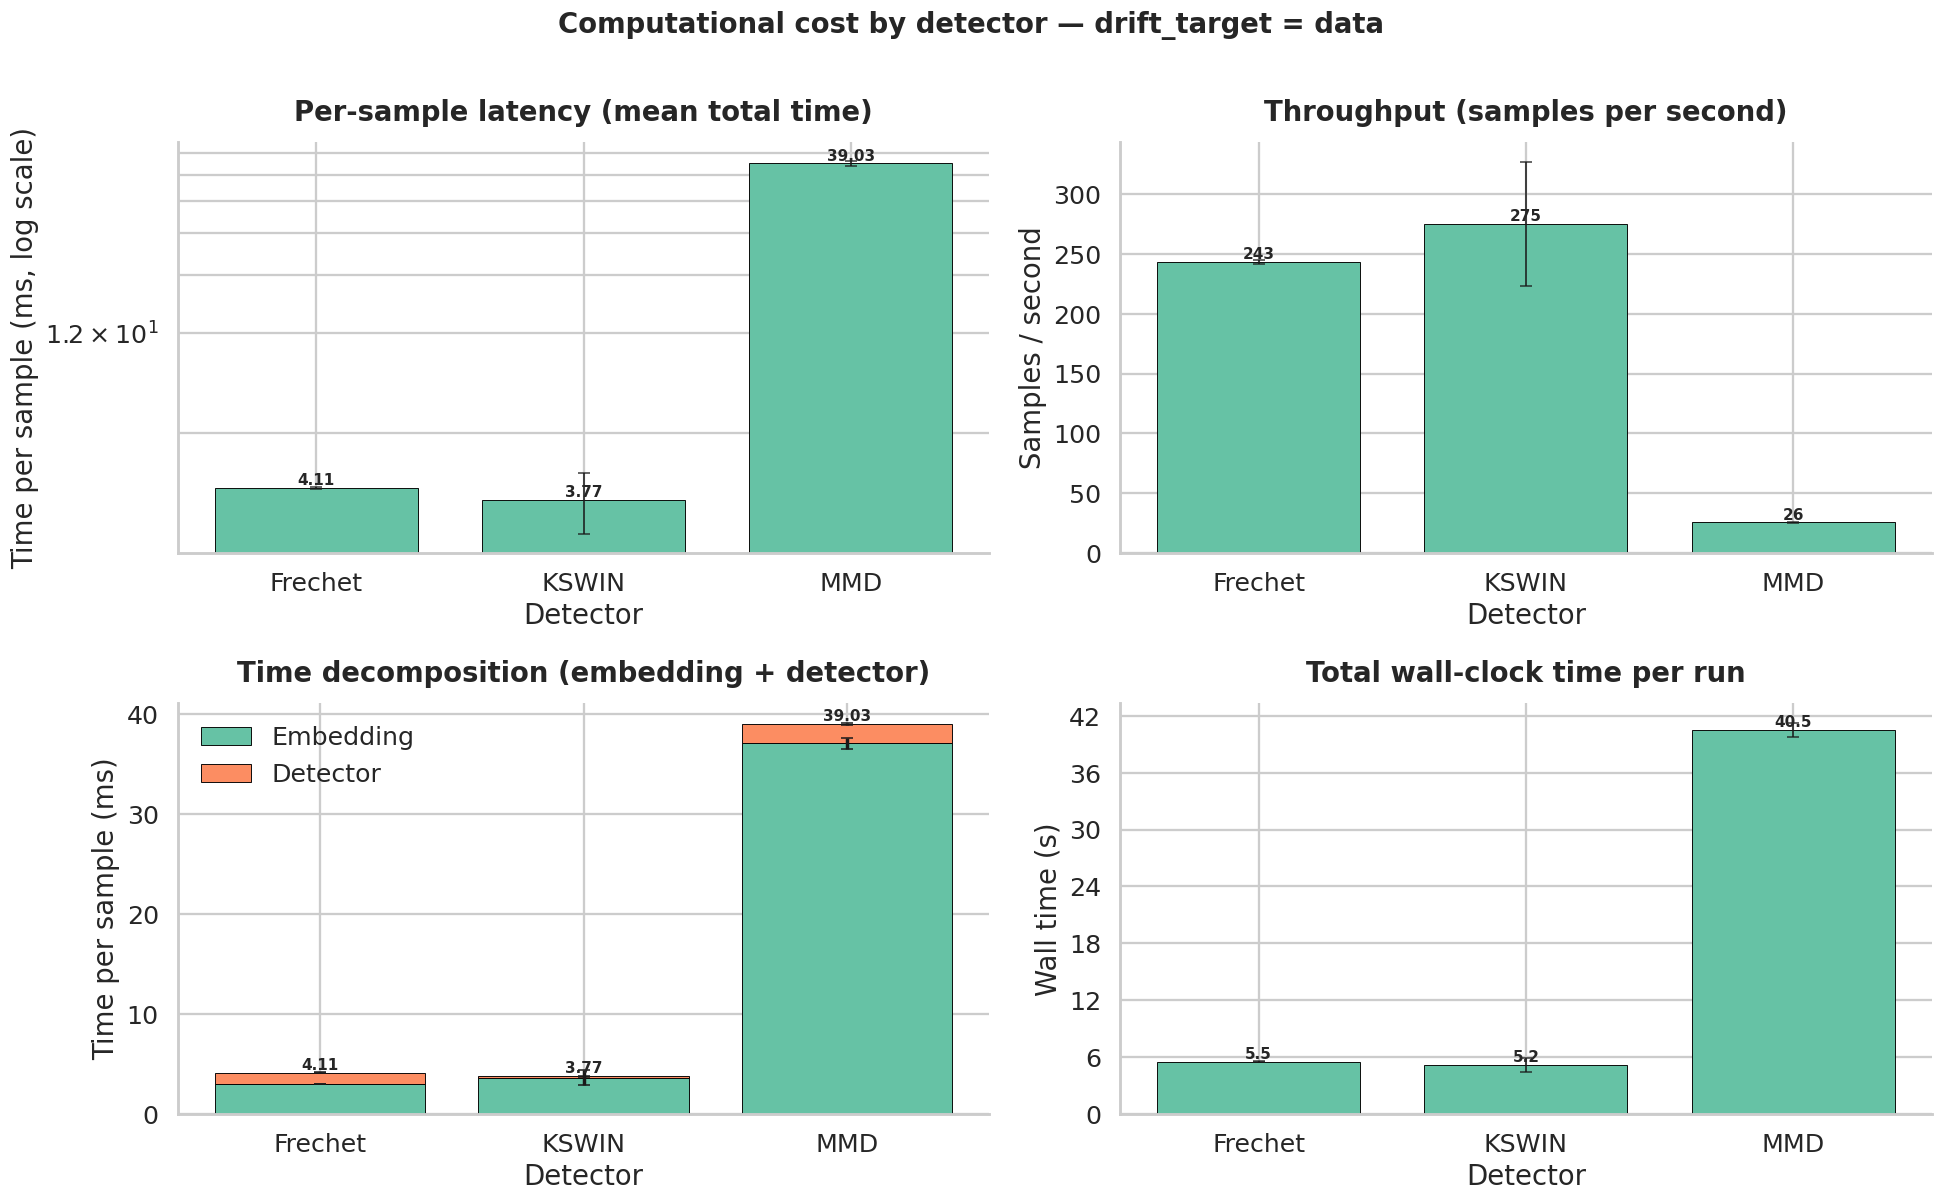

In [8]:
def plot_compute_overview(slice_df: pd.DataFrame, target_label: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 11))

    grouped_bar(
        slice_df,
        metric_mean="mean_total_time_ms_mean",
        metric_std="mean_total_time_ms_std",
        title="Per-sample latency (mean total time)",
        ylabel="Time per sample (ms, log scale)",
        ax=axes[0, 0],
        value_fmt="{:.2f}",
        log=True,
    )

    grouped_bar(
        slice_df,
        metric_mean="throughput_samples_per_s_mean",
        metric_std="throughput_samples_per_s_std",
        title="Throughput (samples per second)",
        ylabel="Samples / second",
        ax=axes[0, 1],
        value_fmt="{:.0f}",
    )

    ax = axes[1, 0]
    if slice_df.empty:
        ax.text(
            0.5,
            0.5,
            "No data available",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
        ax.set_title("Time decomposition (embedding vs detector)")
        ax.set_axis_off()
    else:
        detectors = _detector_order(slice_df)
        per_det = (
            slice_df.groupby("detector_pretty")
            .mean(numeric_only=True)
            .reindex(detectors)
        )
        emb = per_det["mean_embedding_time_ms_mean"].to_numpy()
        det = per_det["mean_detector_time_ms_mean"].to_numpy()
        emb_std = per_det["mean_embedding_time_ms_std"].to_numpy()
        det_std = per_det["mean_detector_time_ms_std"].to_numpy()
        x = np.arange(len(detectors))
        colors = sns.color_palette(PALETTE, 2)
        ax.bar(
            x,
            emb,
            label="Embedding",
            color=colors[0],
            yerr=emb_std,
            capsize=4,
            edgecolor="black",
            linewidth=0.6,
        )
        ax.bar(
            x,
            det,
            bottom=emb,
            label="Detector",
            color=colors[1],
            yerr=det_std,
            capsize=4,
            edgecolor="black",
            linewidth=0.6,
        )
        for xi, e, d in zip(x, emb, det):
            total = (0 if np.isnan(e) else e) + (0 if np.isnan(d) else d)
            ax.text(
                xi,
                total,
                f"{total:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="semibold",
            )
        ax.set_xticks(x)
        ax.set_xticklabels(detectors)
        ax.set_xlabel("Detector")
        ax.set_ylabel("Time per sample (ms)")
        ax.set_title("Time decomposition (embedding + detector)")
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

    grouped_bar(
        slice_df,
        metric_mean="wall_time_s_mean",
        metric_std="wall_time_s_std",
        title="Total wall-clock time per run",
        ylabel="Wall time (s)",
        ax=axes[1, 1],
        value_fmt="{:.1f}",
    )

    fig.suptitle(
        f"Computational cost by detector \u2014 drift_target = {target_label}",
        fontsize=18,
        fontweight="bold",
        y=1.0,
    )
    plt.tight_layout()
    plt.show()


plot_compute_overview(data_agg, "data")

## 4. Summary table

Compact view of the most important columns &mdash; suitable for slides. Means and standard deviations are merged into a single "`mean &plusmn; std`" cell.

In [9]:
SUMMARY_METRICS = [
    ("recall", "Recall", 2),
    ("precision", "Precision", 2),
    ("f1", "F1", 2),
    ("mean_detection_delay", "Mean delay (samples)", 1),
    ("mean_total_time_ms", "Latency (ms / sample)", 2),
    ("throughput_samples_per_s", "Throughput (samples / s)", 0),
    ("wall_time_s", "Wall time (s)", 1),
]


def _fmt(mean: float, std: float, decimals: int) -> str:
    if pd.isna(mean):
        return "\u2014"
    if pd.isna(std):
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} \u00b1 {std:.{decimals}f}"


def summary_table(slice_df: pd.DataFrame) -> pd.DataFrame:
    if slice_df.empty:
        return pd.DataFrame()
    rows = []
    for _, r in slice_df.sort_values(["drift_type", "detector"]).iterrows():
        row = {
            "Detector": pretty(DETECTOR_LABELS, r["detector"]),
            "Drift type": pretty(DRIFT_TYPE_LABELS, r["drift_type"]),
            "Modality": pretty(MODALITY_LABELS, r["modality"]),
            "Trials": int(r["trials"]),
        }
        for base, label, dec in SUMMARY_METRICS:
            row[label] = _fmt(r.get(f"{base}_mean"), r.get(f"{base}_std"), dec)
        rows.append(row)
    return pd.DataFrame(rows)


data_summary = summary_table(data_agg)


def style_summary(df: pd.DataFrame, caption: str):
    if df.empty:
        print(f"[{caption}] No data available.")
        return df
    return (
        df.style.set_caption(caption)
        .set_properties(**{"text-align": "center"})
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("font-size", "14pt"),
                        ("font-weight", "bold"),
                        ("padding", "6px"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("background-color", "#f2f2f2"),
                    ],
                },
            ]
        )
        .hide(axis="index")
    )


style_summary(data_summary, "Drift detection benchmark \u2014 drift_target = data")

Detector,Drift type,Modality,Trials,Recall,Precision,F1,Mean delay (samples),Latency (ms / sample),Throughput (samples / s),Wall time (s)
Frechet,Gradual recurrent,Multimodal,10,0.73 ± 0.25,0.41 ± 0.25,0.48 ± 0.22,71.6 ± 40.7,4.11 ± 0.03,243 ± 2,5.5 ± 0.0
KSWIN,Gradual recurrent,Multimodal,10,0.65 ± 0.31,0.35 ± 0.19,0.44 ± 0.22,100.5 ± 86.4,3.77 ± 0.80,275 ± 52,5.2 ± 0.8
MMD,Gradual recurrent,Multimodal,10,0.73 ± 0.37,0.40 ± 0.22,0.51 ± 0.28,57.2 ± 42.9,39.03 ± 0.62,26 ± 0,40.5 ± 0.8


## 5. Quick takeaways (drift_target = data)

In [10]:
def quick_takeaways(slice_df: pd.DataFrame, target_label: str) -> None:
    if slice_df.empty:
        print(f"No rows for drift_target = {target_label}.")
        return

    def best(col: str, direction: str = "max"):
        df = slice_df.dropna(subset=[col])
        if df.empty:
            return None, None
        idx = df[col].idxmax() if direction == "max" else df[col].idxmin()
        row = df.loc[idx]
        return pretty(DETECTOR_LABELS, row["detector"]), row[col]

    rec_det, rec_v = best("recall_mean", "max")
    f1_det, f1_v = best("f1_mean", "max")
    prec_det, prec_v = best("precision_mean", "max")
    delay_det, delay_v = best("mean_detection_delay_mean", "min")
    fast_det, fast_v = best("mean_total_time_ms_mean", "min")
    thr_det, thr_v = best("throughput_samples_per_s_mean", "max")

    print(f"Highlights for drift_target = {target_label}")
    print("-" * 56)
    if rec_det:
        print(f"  Highest recall:        {rec_det:>14}  ({rec_v:.2f})")
    if prec_det:
        print(f"  Highest precision:     {prec_det:>14}  ({prec_v:.2f})")
    if f1_det:
        print(f"  Best F1:               {f1_det:>14}  ({f1_v:.2f})")
    if delay_det:
        print(f"  Fastest to detect:     {delay_det:>14}  ({delay_v:.1f} samples)")
    if fast_det:
        print(f"  Lowest per-sample lat: {fast_det:>14}  ({fast_v:.2f} ms)")
    if thr_det:
        print(f"  Highest throughput:    {thr_det:>14}  ({thr_v:.0f} samples/s)")


quick_takeaways(data_agg, "data")

Highlights for drift_target = data
--------------------------------------------------------
  Highest recall:               Frechet  (0.73)
  Highest precision:            Frechet  (0.41)
  Best F1:                          MMD  (0.51)
  Fastest to detect:                MMD  (57.2 samples)
  Lowest per-sample lat:          KSWIN  (3.77 ms)
  Highest throughput:             KSWIN  (275 samples/s)


---

## 6. Performance-target results

The cells below mirror the analysis above, but for `drift_target = performance` &mdash; error-based detectors that watch the downstream classifier (ADWIN, HDDM-W, KSWIN, Page-Hinkley).

In [11]:
TARGET = "performance"
perf_agg_view = slice_target(agg, TARGET)
perf_gran_view = slice_target(granular, TARGET)

if perf_agg_view.empty:
    print(f"No rows found for drift_target = {TARGET}. Skipping all performance plots.")
else:
    print(
        f"Loaded {len(perf_agg_view)} aggregated rows / {len(perf_gran_view)} granular trials for drift_target = {TARGET}."
    )
perf_agg_view.head()

Loaded 4 aggregated rows / 40 granular trials for drift_target = performance.


,drift_target,detector,drift_type,modality,trials,recall_mean,recall_std,recall_count,precision_mean,precision_std,...,classifier_case1_accuracy_count,classifier_case2_accuracy_mean,classifier_case2_accuracy_std,classifier_case2_accuracy_count,classifier_case2_replacements_mean,classifier_case2_replacements_std,classifier_case2_replacements_count,detector_pretty,drift_type_pretty,modality_pretty
3,performance,adwin,gradual_recurrent,both,10,0.000000,0.000000,10,0.00,0.000000,...,10,0.6159,0.021414,10,0.0,0.000000,10,ADWIN,Gradual recurrent,Multimodal
4,performance,hddm_w,gradual_recurrent,both,10,0.116667,0.249072,10,0.15,0.337474,...,10,0.6035,0.026459,10,1.3,0.948683,10,HDDM-W,Gradual recurrent,Multimodal
5,performance,kswin,gradual_recurrent,both,10,0.100000,0.210819,10,0.10,0.210819,...,10,0.6048,0.019719,10,1.2,0.632456,10,KSWIN,Gradual recurrent,Multimodal
6,performance,page_hinkley,gradual_recurrent,both,10,0.100000,0.210819,10,0.20,0.421637,...,10,0.6122,0.019217,10,0.6,0.516398,10,Page-Hinkley,Gradual recurrent,Multimodal


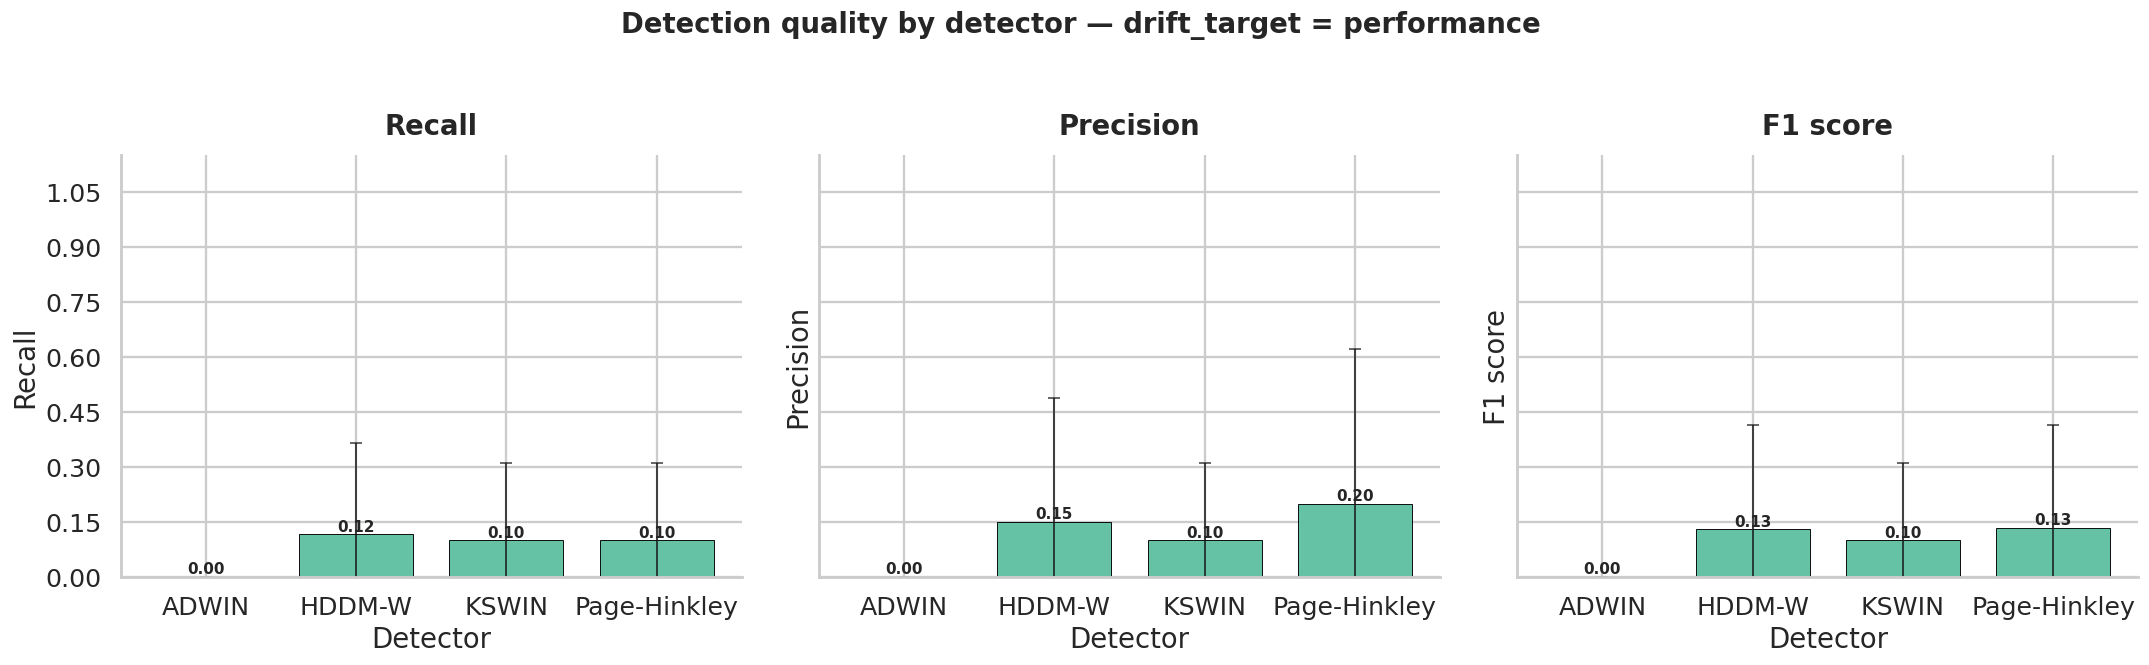

In [12]:
if not perf_agg_view.empty:
    plot_detection_quality(perf_agg_view, TARGET)
else:
    show_no_data(f"Detection quality \u2014 drift_target = {TARGET}")

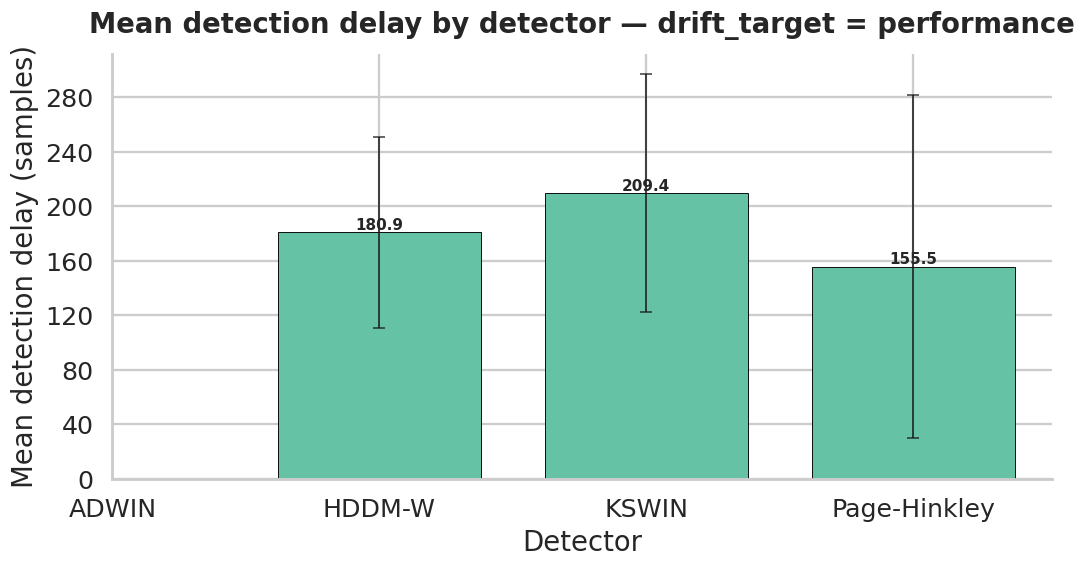

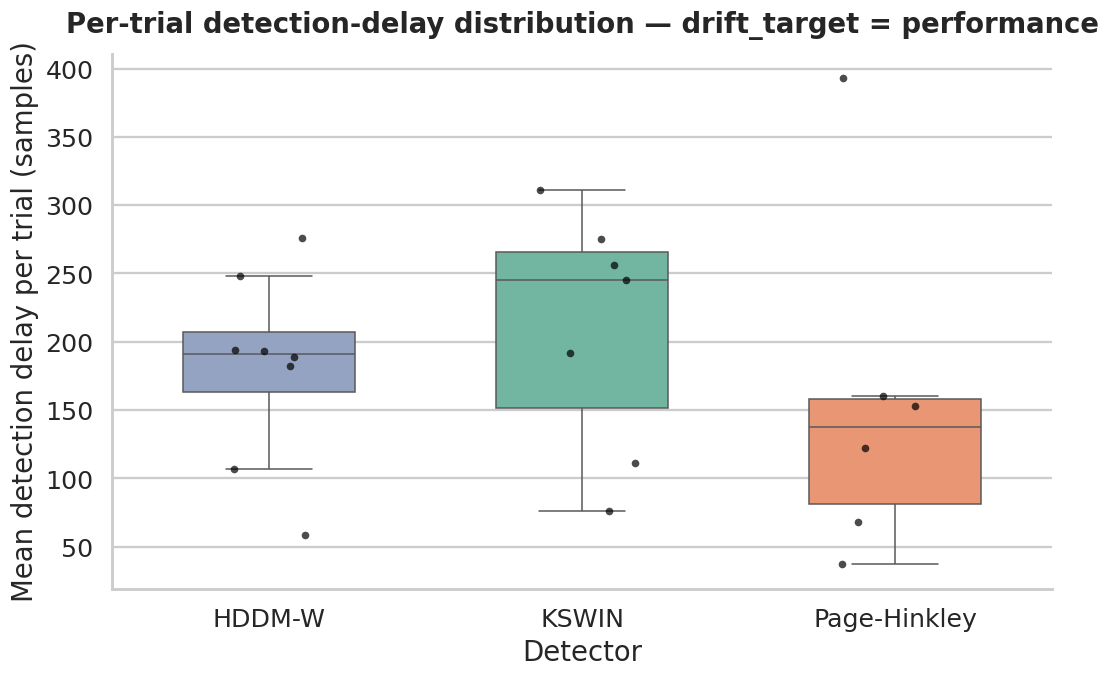

In [13]:
if not perf_agg_view.empty:
    plot_detection_delay(perf_agg_view, TARGET)
    plot_delay_distribution(perf_gran_view, TARGET)
else:
    show_no_data(f"Detection delay \u2014 drift_target = {TARGET}")

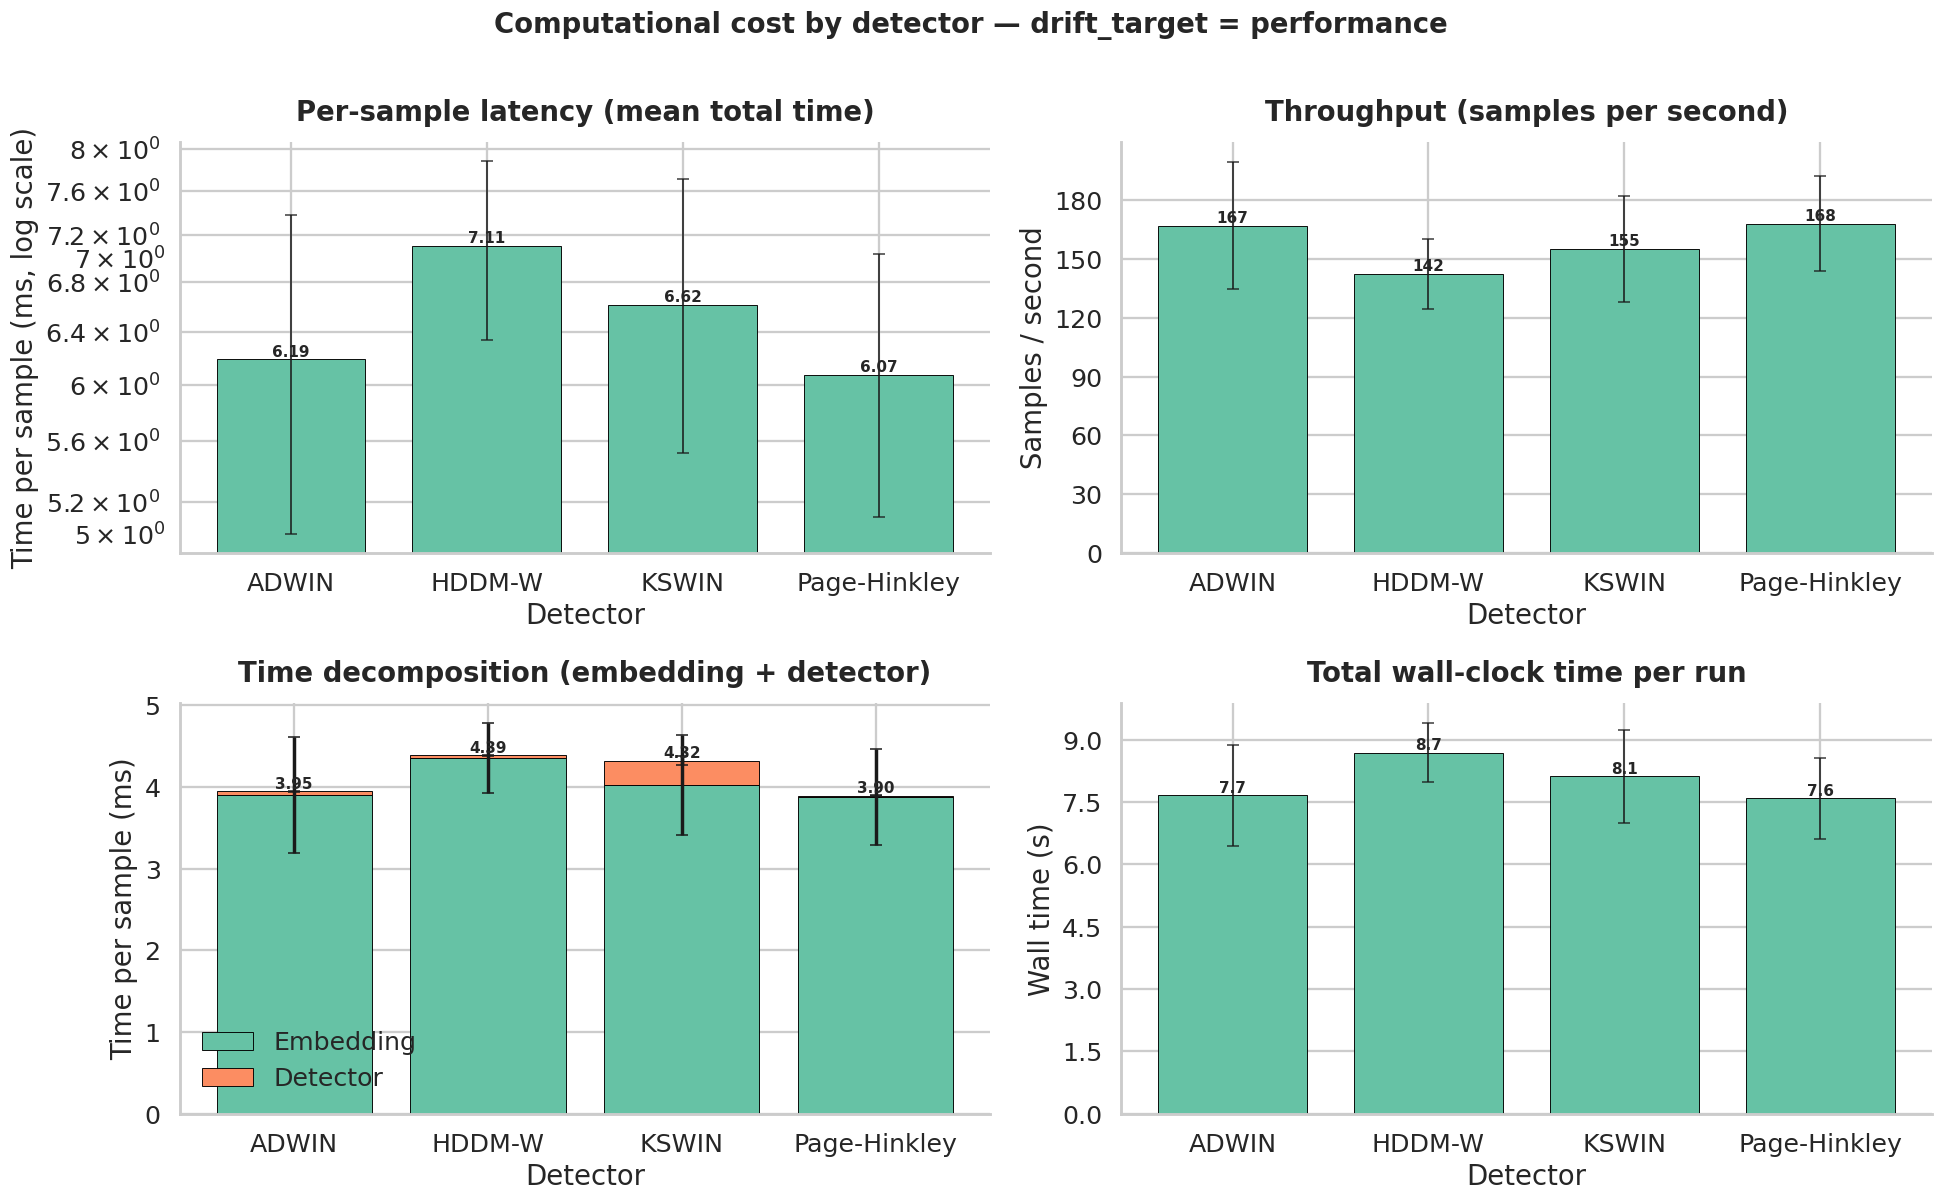

In [14]:
if not perf_agg_view.empty:
    plot_compute_overview(perf_agg_view, TARGET)
else:
    show_no_data(f"Computational cost \u2014 drift_target = {TARGET}")

In [15]:
perf_summary = summary_table(perf_agg_view)
style_summary(perf_summary, f"Drift detection benchmark \u2014 drift_target = {TARGET}")

Detector,Drift type,Modality,Trials,Recall,Precision,F1,Mean delay (samples),Latency (ms / sample),Throughput (samples / s),Wall time (s)
ADWIN,Gradual recurrent,Multimodal,10,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,—,6.19 ± 1.19,167 ± 32,7.7 ± 1.2
HDDM-W,Gradual recurrent,Multimodal,10,0.12 ± 0.25,0.15 ± 0.34,0.13 ± 0.28,180.9 ± 70.1,7.11 ± 0.77,142 ± 18,8.7 ± 0.7
KSWIN,Gradual recurrent,Multimodal,10,0.10 ± 0.21,0.10 ± 0.21,0.10 ± 0.21,209.4 ± 87.4,6.62 ± 1.10,155 ± 27,8.1 ± 1.1
Page-Hinkley,Gradual recurrent,Multimodal,10,0.10 ± 0.21,0.20 ± 0.42,0.13 ± 0.28,155.5 ± 125.9,6.07 ± 0.96,168 ± 24,7.6 ± 1.0


In [16]:
quick_takeaways(perf_agg_view, TARGET)

Highlights for drift_target = performance
--------------------------------------------------------
  Highest recall:                HDDM-W  (0.12)
  Highest precision:       Page-Hinkley  (0.20)
  Best F1:                 Page-Hinkley  (0.13)
  Fastest to detect:       Page-Hinkley  (155.5 samples)
  Lowest per-sample lat:   Page-Hinkley  (6.07 ms)
  Highest throughput:      Page-Hinkley  (168 samples/s)


### Classifier accuracy underpinning the performance detectors

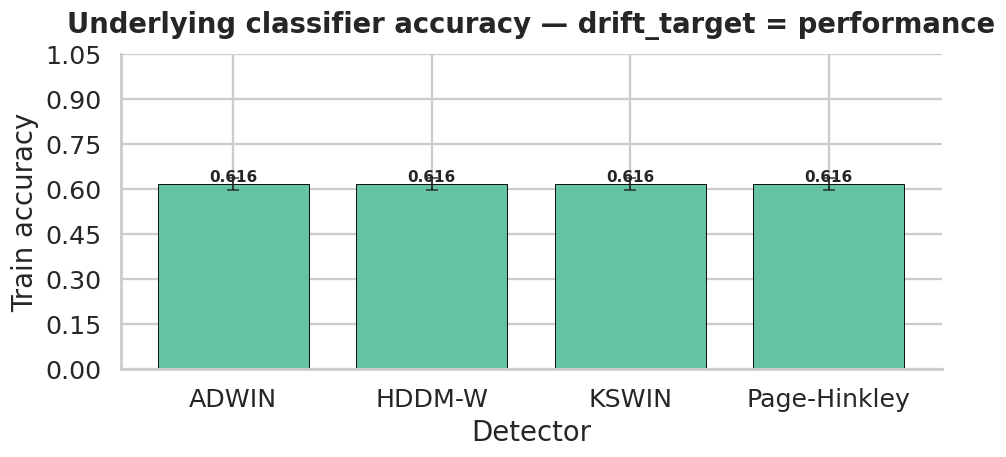

In [17]:
if (
    not perf_agg_view.empty
    and perf_agg_view["classifier_case1_accuracy_mean"].notna().any()
):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    grouped_bar(
        perf_agg_view,
        metric_mean="classifier_case1_accuracy_mean",
        metric_std="classifier_case1_accuracy_std",
        title=f"Underlying classifier accuracy \u2014 drift_target = {TARGET}",
        ylabel="Train accuracy",
        ax=ax,
        ylim=(0, 1.05),
        value_fmt="{:.3f}",
    )
    plt.tight_layout()
    plt.show()
else:
    show_no_data(f"Classifier train accuracy \u2014 drift_target = {TARGET}")

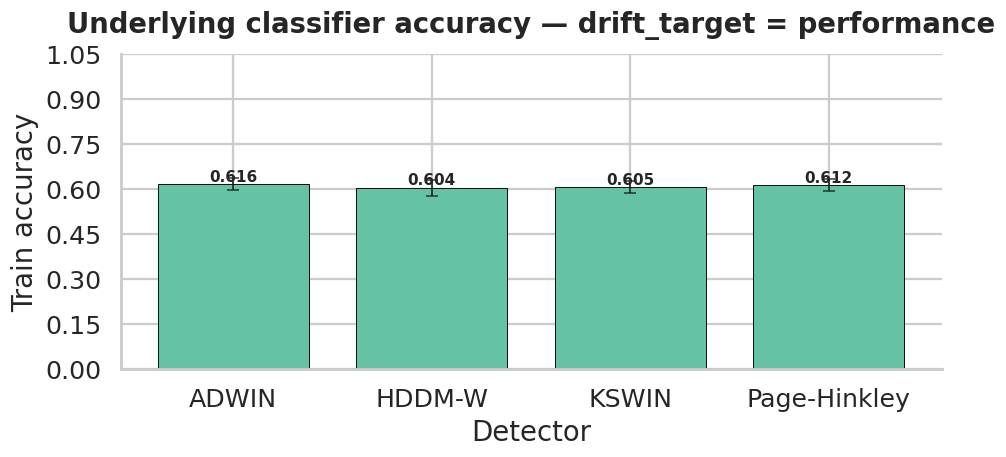

In [18]:
if (
    not perf_agg_view.empty
    and perf_agg_view["classifier_case2_accuracy_mean"].notna().any()
):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    grouped_bar(
        perf_agg_view,
        metric_mean="classifier_case2_accuracy_mean",
        metric_std="classifier_case2_accuracy_std",
        title=f"Underlying classifier accuracy \u2014 drift_target = {TARGET}",
        ylabel="Train accuracy",
        ax=ax,
        ylim=(0, 1.05),
        value_fmt="{:.3f}",
    )
    plt.tight_layout()
    plt.show()
else:
    show_no_data(f"Classifier train accuracy \u2014 drift_target = {TARGET}")